=== Path Check ===
  OK      Flooded        → /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image
  OK      Non-Flooded    → /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image
  OK      Unlabeled      → /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Unlabeled/image

=== Dataset Split (80/20 from labeled) ===
  Train : 317  (40 flooded | 277 non-flooded)
  Val   : 81  (11 flooded | 70 non-flooded)
  Unlabeled for pseudo-labeling: 1047

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

=== MobileNetV2 (pretrained ImageNet) ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 122MB/s]


  Head  : 1280 → 1  (BCEWithLogitsLoss)
  Optim : Adam  lr=0.0001  batch=16

════════════════════════════════════════════════════════════════════════════════════════
 Ep │    λ │     α │     Loss │    Acc │     F1 │   Prec │    Rec │    AUC
════════════════════════════════════════════════════════════════════════════════════════
  1 │ 0.20 │ 0.000 │   0.3263 │ 0.9630 │ 0.8571 │ 0.9000 │ 0.8182 │ 0.9026
  2 │ 0.20 │ 0.000 │   0.0643 │ 0.9506 │ 0.8182 │ 0.8182 │ 0.8182 │ 0.9208
  3 │ 0.20 │ 0.000 │   0.0494 │ 0.9506 │ 0.8000 │ 0.8889 │ 0.7273 │ 0.8727
  4 │ 0.20 │ 0.000 │   0.0158 │ 0.9630 │ 0.8571 │ 0.9000 │ 0.8182 │ 0.9221
  5 │ 0.20 │ 0.000 │   0.0188 │ 0.9630 │ 0.8571 │ 0.9000 │ 0.8182 │ 0.9065
  6 │ 0.20 │ 0.000 │   0.0193 │ 0.9506 │ 0.8000 │ 0.8889 │ 0.7273 │ 0.9078
  7 │ 0.20 │ 0.000 │   0.0084 │ 0.9630 │ 0.8571 │ 0.9000 │ 0.8182 │ 0.8610
  8 │ 0.20 │ 0.000 │   0.0121 │ 0.9630 │ 0.8571 │ 0.9000 │ 0.8182 │ 0.8922
  9 │ 0.20 │ 0.000 │   0.0235 │ 0.9383 │ 0.7368 │ 0.8750 │ 0.6364 │ 0.

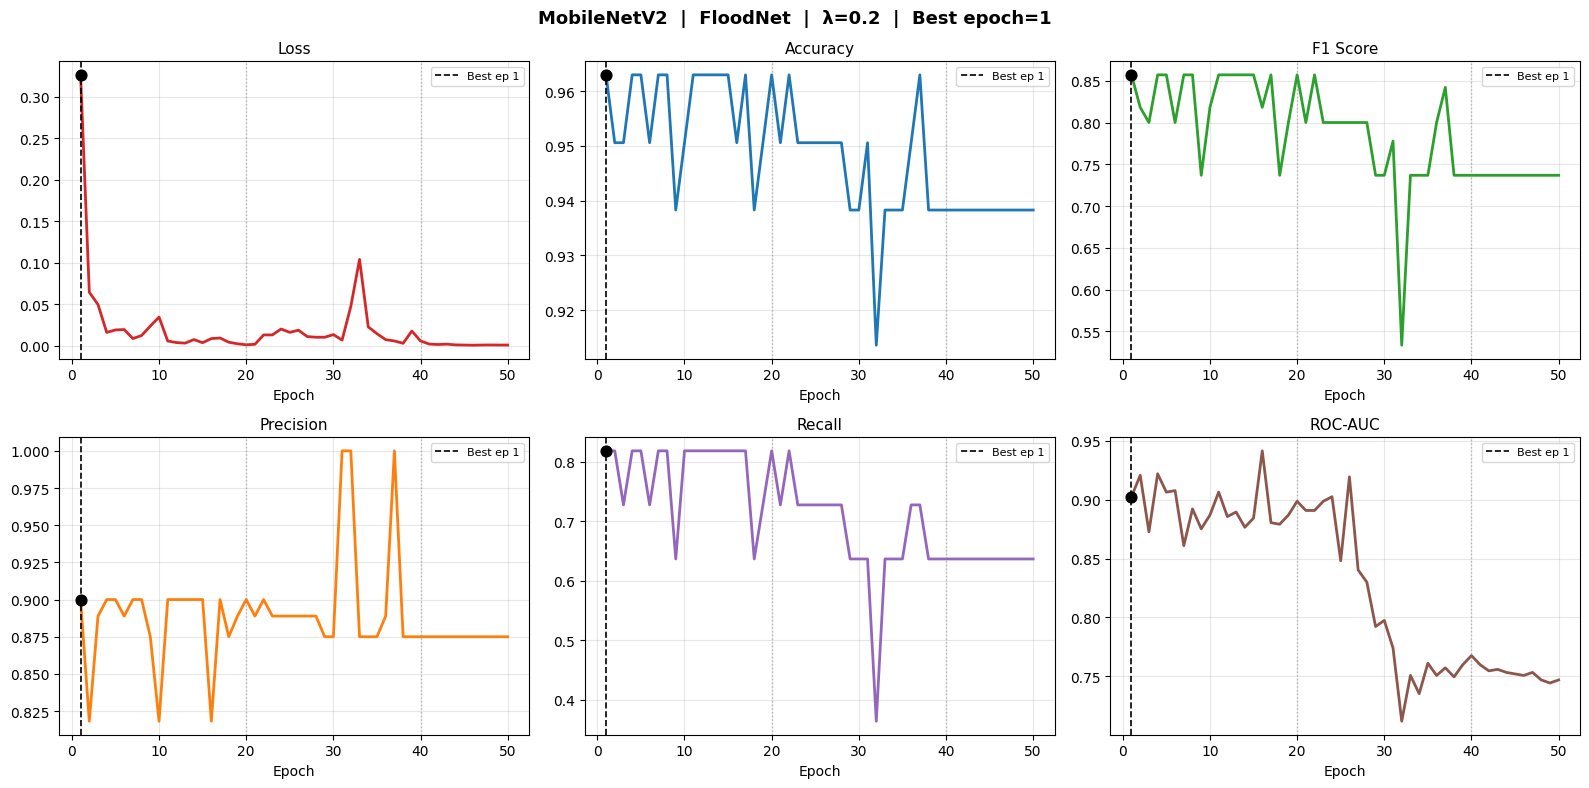

Saved → training_curves.png


In [14]:
# ╔══════════════════════════════════════════════════════════════════════╗
#  FloodNet — MobileNetV2 Semi-Supervised Training
#  Paper : "Flood or Non-Flooded" (Jackson et al., Water 2023, 15, 875)
#  λ=0.2 | 50 epochs | Adam lr=0.0001 | batch=16
#
#  LABEL STRATEGY (final):
#  - The CSV is only a class legend (not per-image labels)
#  - Track 2 JSON has questions but NO answers
#  - Val/Test folders have NO label source in this Kaggle dataset
#  - SOLUTION: split the 398 labeled images 80/20 → train/val
#              use all 1047 unlabeled images for pseudo-labeling
# ╚══════════════════════════════════════════════════════════════════════╝

import os, copy, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── 1. PATHS ───────────────────────────────────────────────────────────
BASE = Path(
    "/kaggle/input/datasets/aletbm/"
    "aerial-imagery-dataset-floodnet-challenge/"
    "FloodNet Challenge - Track 1"
)
FLOODED_DIR    = BASE / "Train/Labeled/Flooded/image"
NONFLOODED_DIR = BASE / "Train/Labeled/Non-Flooded/image"
UNLABELED_DIR  = BASE / "Train/Unlabeled/image"
EXTS = {".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"}

print("=== Path Check ===")
for name, p in [("Flooded", FLOODED_DIR),
                ("Non-Flooded", NONFLOODED_DIR),
                ("Unlabeled", UNLABELED_DIR)]:
    status = "OK" if Path(p).exists() else "MISSING"
    print(f"  {status:7} {name:<14} → {p}")

# ── 2. Collect all labeled samples then split 80/20 ───────────────────
def collect(folder, label):
    paths = [str(p) for p in Path(folder).iterdir() if p.suffix in EXTS]
    return [(p, label) for p in paths]

flooded_s    = collect(FLOODED_DIR,    1)   # 51 images
nonflooded_s = collect(NONFLOODED_DIR, 0)   # 347 images

# Shuffle each class separately then split — keeps class ratio in both sets
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

train_samples = f_train + nf_train   # ~318 images
val_samples   = f_val   + nf_val     # ~80  images

n_f_tr  = len(f_train)
n_nf_tr = len(nf_train)
n_tr    = len(train_samples)

print(f"\n=== Dataset Split (80/20 from labeled) ===")
print(f"  Train : {n_tr}  ({n_f_tr} flooded | {n_nf_tr} non-flooded)")
print(f"  Val   : {len(val_samples)}  ({len(f_val)} flooded | {len(nf_val)} non-flooded)")
print(f"  Unlabeled for pseudo-labeling: ", end="")

unlabeled_paths = [str(p) for p in Path(UNLABELED_DIR).iterdir()
                   if p.suffix in EXTS]
print(len(unlabeled_paths))

# ── 3. Hyper-parameters ────────────────────────────────────────────────
IMG_SIZE = 224
BATCH    = 16
LR       = 1e-4
E        = 50
E_ia     = 20      # labeled-only phase  (E_i^a in paper)
E_fa     = 40      # alpha ramp ends     (E_f^a in paper)
a_i, a_f = 0.0, 1.0
LAMBDA   = 0.2     # uncertainty offset — best per paper
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nDevice : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

def get_alpha(ep):
    if ep < E_ia: return a_i
    if ep < E_fa: return ((a_f-a_i)/(E_fa-E_ia))*(ep-E_ia)+a_i
    return a_f

# ── 4. Transforms ─────────────────────────────────────────────────────
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── 5. Datasets ───────────────────────────────────────────────────────

class LabeledDS(Dataset):
    def __init__(self, samples, tfm=None):
        self.samples, self.tfm = samples, tfm
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.tfm: img = self.tfm(img)
        return img, torch.tensor(lbl, dtype=torch.float32)


class UnlabeledDS(Dataset):
    def __init__(self, paths, tfm=None):
        self.paths, self.tfm = paths, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.tfm: img = self.tfm(img)
        return img, self.paths[i]


# ── 6. Dataloaders ────────────────────────────────────────────────────

# Weighted sampler on training set (fix 51 vs 347 imbalance)
cw      = [n_tr/(2*n_nf_tr), n_tr/(2*n_f_tr)]   # [w_class0, w_class1]
sw      = [cw[int(s[1])] for s in train_samples]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

train_ds   = LabeledDS(train_samples, tfm)
val_ds     = LabeledDS(val_samples,   tfm)
unl_ds     = UnlabeledDS(unlabeled_paths, tfm)

train_ldr  = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                        num_workers=2, pin_memory=True)
val_ldr    = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
unl_ldr    = DataLoader(unl_ds,   batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)

# ── 7. MobileNetV2 ────────────────────────────────────────────────────
print("\n=== MobileNetV2 (pretrained ImageNet) ===")
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 1)   # 1280 → 1
)
model     = model.to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()
print(f"  Head  : {model.last_channel} → 1  (BCEWithLogitsLoss)")
print(f"  Optim : Adam  lr={LR}  batch={BATCH}")

# ── 8. Evaluation ─────────────────────────────────────────────────────
def evaluate(loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 9. Training loop (Algorithm 1) ────────────────────────────────────
history    = []
best_f1    = -1
best_epoch = -1
best_row   = {}
best_state = None

print("\n" + "═"*88)
print(f"{'Ep':>3} │ {'λ':>4} │ {'α':>5} │ {'Loss':>8} │ "
      f"{'Acc':>6} │ {'F1':>6} │ {'Prec':>6} │ {'Rec':>6} │ {'AUC':>6}")
print("═"*88)

for ep in range(E):
    model.train()
    alpha = get_alpha(ep)
    total_loss, n_batches = 0.0, 0

    # ── Phase A : labeled pass ───────────────────────────────
    for imgs, lbls in train_ldr:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(1), lbls)
        loss.backward(); optimizer.step()
        total_loss += loss.item(); n_batches += 1

    # ── Phase B : score unlabeled → pseudo-labels ────────────
    #   Algorithm 1 lines 8-15:
    #   p ≤ 0.5−λ  → non-flooded (0)
    #   p ≥ 0.5+λ  → flooded     (1)
    #   else        → ignore (uncertain margin)
    if alpha > 0:
        model.eval()
        p_imgs, p_lbls = [], []
        with torch.no_grad():
            for imgs, _ in unl_ldr:
                imgs  = imgs.to(DEVICE)
                probs = torch.sigmoid(model(imgs).squeeze(1)).cpu().numpy()
                for i, pv in enumerate(probs):
                    if pv <= 0.5 - LAMBDA:
                        p_imgs.append(imgs[i].cpu())
                        p_lbls.append(torch.tensor(0.0))
                    elif pv >= 0.5 + LAMBDA:
                        p_imgs.append(imgs[i].cpu())
                        p_lbls.append(torch.tensor(1.0))

        # ── Phase C : fine-tune on pseudo-labeled ────────────
        if p_imgs:
            model.train()
            for s in range(0, len(p_imgs), BATCH):
                pi = torch.stack(p_imgs[s:s+BATCH]).to(DEVICE)
                pl = torch.stack(p_lbls[s:s+BATCH]).to(DEVICE)
                optimizer.zero_grad()
                loss_u = alpha * criterion(model(pi).squeeze(1), pl)
                loss_u.backward(); optimizer.step()
                total_loss += loss_u.item(); n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    acc, f1, prec, rec, roc = evaluate(val_ldr)

    row = dict(epoch=ep+1, lambda_=LAMBDA, alpha=round(alpha,4),
               loss=round(avg_loss,4), accuracy=round(acc,4),
               f1=round(f1,4), precision=round(prec,4),
               recall=round(rec,4), roc_auc=round(roc,4))
    history.append(row)
    print(f"{ep+1:3d} │ {LAMBDA:4.2f} │ {alpha:5.3f} │ {avg_loss:8.4f} │ "
          f"{acc:6.4f} │ {f1:6.4f} │ {prec:6.4f} │ {rec:6.4f} │ {roc:6.4f}")

    if f1 > best_f1:
        best_f1=f1; best_epoch=ep+1
        best_row=row.copy()
        best_state=copy.deepcopy(model.state_dict())

print("═"*88)

# ── 10. Best epoch summary ────────────────────────────────────────────
print("\n╔══════════════════════════════════════════╗")
print("║   BEST VALIDATION RESULTS  (by F1)      ║")
print("╠══════════════════════════════════════════╣")
for k, v in best_row.items():
    print(f"║  {k:<14} : {str(v):<24}║")
print("╚══════════════════════════════════════════╝")

# ── 11. Save ──────────────────────────────────────────────────────────
df_hist = pd.DataFrame(history)
df_hist.to_csv("/kaggle/working/training_history.csv", index=False)
torch.save(best_state, "/kaggle/working/mobilenetv2_best.pth")
print("\nSaved → training_history.csv  |  mobilenetv2_best.pth")

# ── 12. Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16,8))
fig.suptitle(
    f"MobileNetV2  |  FloodNet  |  λ={LAMBDA}  |  Best epoch={best_epoch}",
    fontsize=13, fontweight="bold"
)
pairs = [("loss","Loss","tab:red"),("accuracy","Accuracy","tab:blue"),
         ("f1","F1 Score","tab:green"),("precision","Precision","tab:orange"),
         ("recall","Recall","tab:purple"),("roc_auc","ROC-AUC","tab:brown")]

for ax, (col, title, color) in zip(axes.flat, pairs):
    ax.plot(df_hist["epoch"], df_hist[col], color=color, linewidth=2)
    ax.axvline(best_epoch, color="black", linestyle="--",
               linewidth=1.2, label=f"Best ep {best_epoch}")
    bv = df_hist.loc[df_hist["epoch"]==best_epoch, col].values[0]
    ax.scatter([best_epoch],[bv], color="black", zorder=5, s=60)
    ax.axvline(E_ia, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.axvline(E_fa, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")